<a href="https://colab.research.google.com/github/Naaish2/Convolutional-Variational-Autoencoder/blob/main/CVAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import keras
import tensorflow as tf
from keras import backend as k

# Proceeding in graph mode as initialized.
k.clear_session()

Dataset loading and Pre-Processing

In [2]:
# import minist dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
image_shape = (28, 28, 1)
latent_dim = 2
# change datatype and reshape data
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((x_train.shape[0],) + image_shape)
x_test = x_test.astype('float32') / 255.
x_test = x_test.reshape((x_test.shape[0],) + image_shape)

Fetch each digit images

In [3]:
# function to fetch 10 images of label 0 to 9
def get_images_1_to_10(x_train, y_train):
    selected_x, selected_y = [], []
    for i in range(10):
        number_index = np.where(y_train == i)[0]
        random_index = np.random.choice(len(number_index), 1, replace=False)
        select_index = number_index[random_index]
        selected_x.append(x_train[select_index[0]])
        selected_y.append(y_train[select_index][0])
    return np.array(selected_x, dtype="float32").reshape((len(selected_x),)+image_shape), np.array(selected_y, dtype="float32")


# select random 10 image of labeled 0 to 9
selected_x, selected_y = get_images_1_to_10(x_train, y_train)

Plot each digit original image

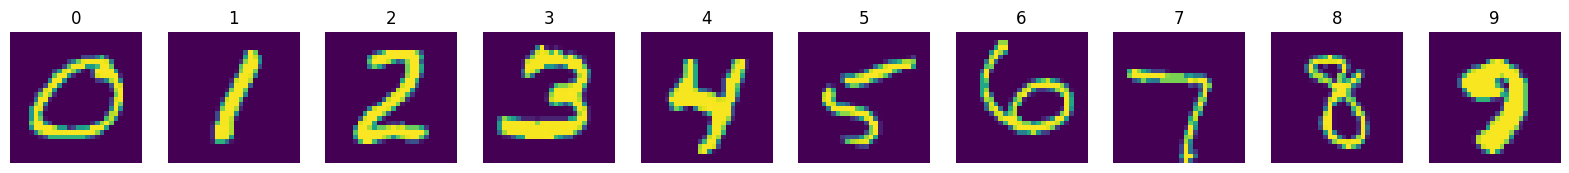

In [4]:
def plot_image(selected_x, selected_y, title=None, save=None):
    ncols = selected_x.shape[0]
    fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=(20, 3))
    for x, y, ax_i in zip(selected_x, selected_y, ax):
        ax_i.imshow(x.reshape((28, 28)))
        ax_i.axis("off")
        ax_i.set_title(int(y))
    if title:
        fig.suptitle(title)
    plt.show()

plot_image(selected_x, selected_y)

Encoder Layer

In [5]:
# Input
encoder_input = tf.keras.Input(shape=image_shape)
# convolutional layer 1
conv_1 = tf.keras.layers.Conv2D(
    filters=32, kernel_size=3, padding="same", activation="relu",)(encoder_input)

# convolutional layer 2
conv_2 = tf.keras.layers.Conv2D(filters=64,
                                kernel_size=3,
                                padding="same",
                                activation="relu",
                                )(conv_1)

# convolutional layer 3
conv_3 = tf.keras.layers.Conv2D(filters=64,
                                kernel_size=3,
                                padding="same",
                                activation="relu",
                                )(conv_2)
# Flatten the data
flatten = tf.keras.layers.Flatten()(conv_3)

# Dense layer 1
encoder_output = tf.keras.layers.Dense(128, activation="relu")(flatten)
z_mu = tf.keras.layers.Dense(latent_dim)(encoder_output)

# Dense layer 2
z_log_sigma = tf.keras.layers.Dense(latent_dim)(encoder_output)

Latent Layer with KL Divergence

In [6]:
class KLDivergenceLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mu, z_log_sigma = inputs
        kl_batch = -0.5 * tf.keras.backend.mean(1 + z_log_sigma -
                                  tf.keras.backend.square(z_mu) -
                                  tf.keras.backend.exp(z_log_sigma), axis=-1)
        self.add_loss(tf.keras.backend.mean(kl_batch))
        return inputs

def sampling(args):
    z_mu, z_log_sigma = args
    epsilon = tf.keras.backend.random_normal(
        shape=(tf.keras.backend.shape(z_mu)[0], latent_dim), mean=0., stddev=1.)
    return z_mu + tf.keras.backend.exp(z_log_sigma) * epsilon

# Apply the KL layer
z_mu_kl, z_log_sigma_kl = KLDivergenceLayer()([z_mu, z_log_sigma])
z = tf.keras.layers.Lambda(sampling, output_shape=(latent_dim,))([z_mu_kl, z_log_sigma_kl])

Decoder Layer

In [7]:
# decoder layer
dense_2 = tf.keras.layers.Dense(128, activation="relu")

# Calculate the units value for dense_3 explicitly
dense_3_units = int(np.prod(tf.keras.backend.int_shape(conv_3)[1:]))
dense_3 = tf.keras.layers.Dense(dense_3_units,
                                activation="relu"
                                )

# Reshape layer
reshape = tf.keras.layers.Reshape(tf.keras.backend.int_shape(conv_3)[1:])

# Deconvolutional layer 1
conv_4 = tf.keras.layers.Conv2DTranspose(filters=64,
                                         kernel_size=3,
                                         padding="same",
                                         activation="relu"
                                         )
# Deconvolutional layer 2
conv_5 = tf.keras.layers.Conv2DTranspose(filters=64,
                                         kernel_size=3,
                                         padding="same",
                                         activation="relu"
                                         )

# Deconvolutional layer 3
conv_6 = tf.keras.layers.Conv2DTranspose(filters=32,
                                         kernel_size=3,
                                         padding="same",
                                         activation="relu"
                                         )

# convolutional layer 4
decoder_output = tf.keras.layers.Conv2D(filters=1,
                                        kernel_size=3,
                                        padding="same",
                                        activation="sigmoid"
                                        )

_dense_2 = dense_2(z)
_dense_3 = dense_3(_dense_2)
_reshape = reshape(_dense_3)
_conv_4 = conv_4(_reshape)
_conv_5 = conv_5(_conv_4)
_conv_6 = conv_6(_conv_5)
_decoder_output = decoder_output(_conv_6)

Defining loss function

In [8]:
def reconstruction_loss(x, z_decoded):
    x = tf.keras.backend.flatten(x)
    z_decoded = tf.keras.backend.flatten(z_decoded)
    return 784 * tf.keras.metrics.binary_crossentropy(x, z_decoded)

Visualizing model structure

In [9]:
cvae = keras.Model(encoder_input, _decoder_output)
cvae.compile(optimizer='rmsprop', loss=reconstruction_loss)
cvae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50176)     │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  6,422,656 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kl_divergence_layer │ [(None, 2),       │          0 │ dense_1[0][0],    │
│ (KLDivergenceLayer) │ (None, 2)]        │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2)         │          0 │ kl_divergence_la… │
│                     │                   │            │ kl_divergence_la… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │        384 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50176)     │  6,472,704 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 28,    │          0 │ dense_4[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 28, 28,    │     36,928 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │     36,928 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 28, 28,    │     18,464 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28, 1) │        289 │ conv2d_transpose… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,044,613 (49.76 MB)

 Trainable params: 13,044,613 (49.76 MB)

 Non-trainable params: 0 (0.00 B)

Train the CVAE Model

In [10]:
import numpy as np
import tensorflow as tf # Added import statement

# Define image_shape and latent_dim here for self-containment
image_shape = (28, 28, 1)
latent_dim = 2

# import minist dataset and pre-process it
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((x_train.shape[0],) + image_shape)
x_test = x_test.astype('float32') / 255.
x_test = x_test.reshape((x_test.shape[0],) + image_shape)

# Re-building the model architecture in the current context
encoder_input = tf.keras.Input(shape=image_shape)
x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(encoder_input)
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
conv_shape = x.shape[1:]
flatten = tf.keras.layers.Flatten()(x)
encoder_output = tf.keras.layers.Dense(128, activation='relu')(flatten)
z_mu = tf.keras.layers.Dense(latent_dim)(encoder_output)
z_log_sigma = tf.keras.layers.Dense(latent_dim)(encoder_output)

class KLDivergenceLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mu, z_log_sigma = inputs
        kl_batch = -0.5 * tf.reduce_mean(1 + z_log_sigma - tf.square(z_mu) - tf.exp(z_log_sigma), axis=-1)
        self.add_loss(tf.reduce_mean(kl_batch))
        return inputs

z_mu_kl, z_log_sigma_kl = KLDivergenceLayer()([z_mu, z_log_sigma])

def sampling(args):
    z_mu, z_log_sigma = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mu)[0], latent_dim))
    return z_mu + tf.exp(z_log_sigma) * epsilon

z = tf.keras.layers.Lambda(sampling)([z_mu_kl, z_log_sigma_kl])

x = tf.keras.layers.Dense(128, activation='relu')(z)
x = tf.keras.layers.Dense(int(np.prod(conv_shape)), activation='relu')(x)
x = tf.keras.layers.Reshape(conv_shape)(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.Conv2DTranspose(32, 3, padding='same', activation='relu')(x)
decoder_output = tf.keras.layers.Conv2D(1, 3, padding='same', activation='sigmoid')(x)

cvae = tf.keras.Model(encoder_input, decoder_output)

def reconstruction_loss(x, z_decoded):
    x_flat = tf.reshape(x, [tf.shape(x)[0], -1])
    z_flat = tf.reshape(z_decoded, [tf.shape(z_decoded)[0], -1])
    return 784 * tf.keras.metrics.binary_crossentropy(x_flat, z_flat)

optimizer = tf.keras.optimizers.RMSprop()

@tf.function
def train_step(data):
    with tf.GradientTape() as tape:
        reconstruction = cvae(data)
        r_loss = tf.reduce_mean(reconstruction_loss(data, reconstruction))
        kl_loss = tf.reduce_sum(cvae.losses)
        total_loss = r_loss + kl_loss
    grads = tape.gradient(total_loss, cvae.trainable_weights)
    optimizer.apply_gradients(zip(grads, cvae.trainable_weights))
    return total_loss

epochs = 10
batch_size = 64
num_batches = int(np.ceil(len(x_train) / batch_size))

print("Starting manual training loop...")
for epoch in range(epochs):
    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    for i in range(num_batches):
        idx = indices[i*batch_size : (i+1)*batch_size]
        batch_x = x_train[idx]
        train_step(batch_x)
    print(f"Epoch {epoch+1}/{epochs} completed.")

Starting manual training loop...
Epoch 1/10 completed.
Epoch 2/10 completed.
Epoch 3/10 completed.
Epoch 4/10 completed.
Epoch 5/10 completed.
Epoch 6/10 completed.
Epoch 7/10 completed.
Epoch 8/10 completed.
Epoch 9/10 completed.
Epoch 10/10 completed.


Artificial Digit image Generations


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step


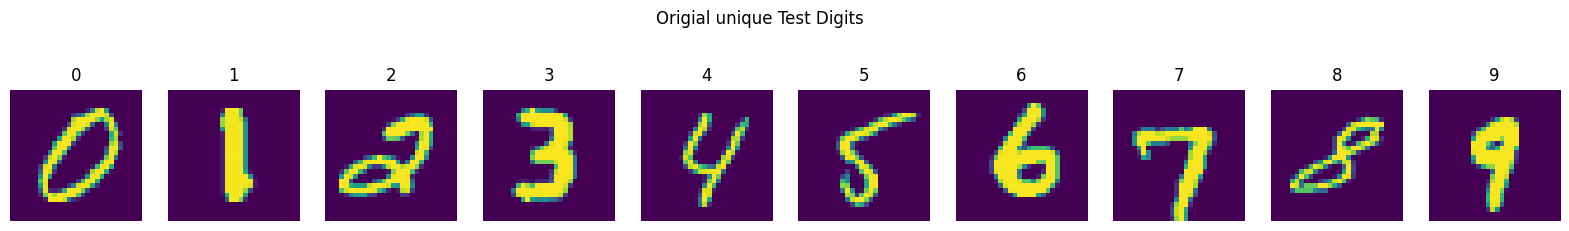

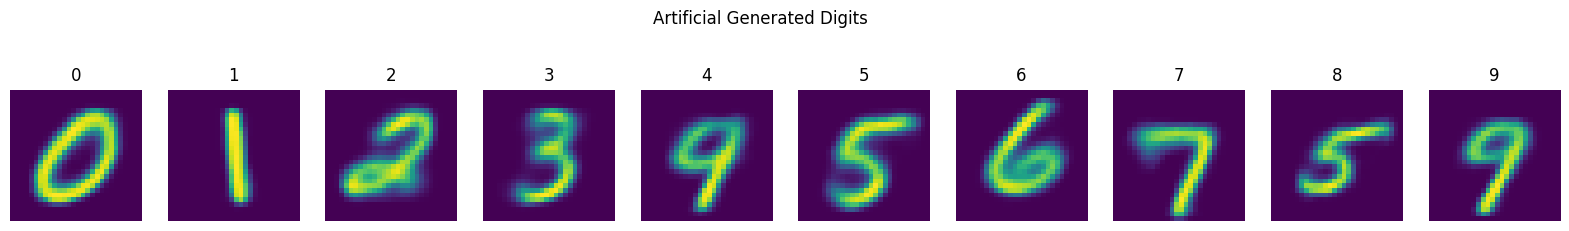

In [11]:
# select random 10 image of labeled 0 to 9 from test dataset
test_x, test_y =  get_images_1_to_10(x_test,y_test)

gen_x = cvae.predict(test_x)

plot_image(test_x,test_y, title="Origial unique Test Digits")
plot_image(gen_x,test_y,title="Artificial Generated Digits")